<a href="https://colab.research.google.com/github/Sundaram001-hu/DL-Lab-Mtech-/blob/main/Experiment9_GAN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 9 - Generative Adversarial Networks
**Dataset:** Fashion-MNIST | **Models:** Vanilla GAN, DCGAN

In [ ]:
!pip install wandb huggingface_hub -q

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 37.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sundaramsahu111 (sundaramsahu111-dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "Yashh-001/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 10
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.3MB/s]

train: 60000  test: 10000


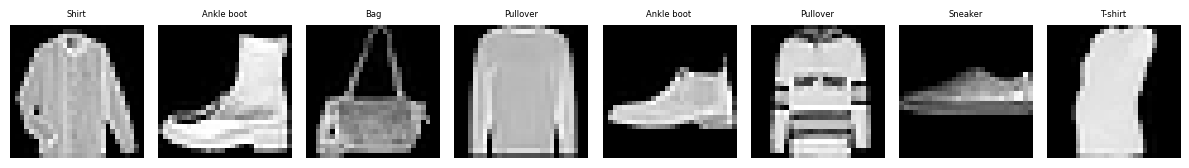

In [ ]:
# normalize to [-1, 1] for GAN training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [ ]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [ ]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [ ]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [ ]:
def get_optimizer(model, name):
    if name == 'adam':
        # betas tuned for GAN stability
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [ ]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [ ]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [ ]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/10  g_loss=1.1938  d_loss=0.4789
  epoch 2/10  g_loss=1.9295  d_loss=0.4450
  epoch 3/10  g_loss=2.0478  d_loss=0.4640
  epoch 4/10  g_loss=1.7441  d_loss=0.4698
  epoch 5/10  g_loss=1.4140  d_loss=0.5374


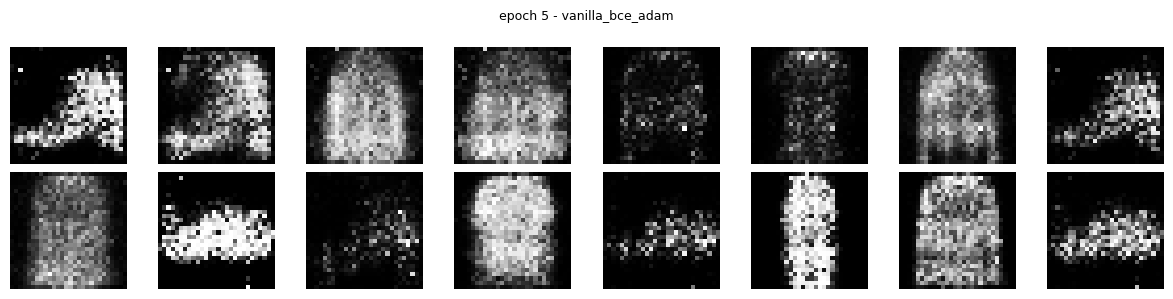

  epoch 6/10  g_loss=1.2907  d_loss=0.5731
  epoch 7/10  g_loss=1.2866  d_loss=0.5688
  epoch 8/10  g_loss=1.2269  d_loss=0.5830


In [ ]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/10  g_loss=1.1391  d_loss=0.4889
  epoch 2/10  g_loss=1.7130  d_loss=0.5064
  epoch 3/10  g_loss=1.7882  d_loss=0.4788
  epoch 4/10  g_loss=1.5839  d_loss=0.4986
  epoch 5/10  g_loss=1.5735  d_loss=0.4938


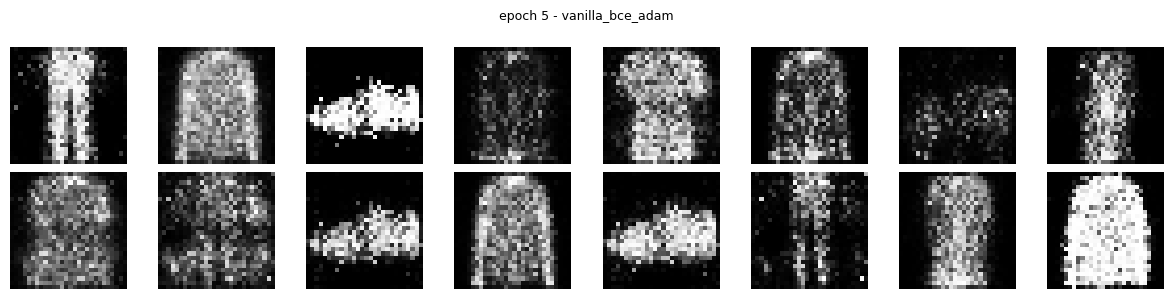

  epoch 6/10  g_loss=1.3441  d_loss=0.5533
  epoch 7/10  g_loss=1.2527  d_loss=0.5752
  epoch 8/10  g_loss=1.1456  d_loss=0.5961
  epoch 9/10  g_loss=1.1110  d_loss=0.6056
  epoch 10/10  g_loss=1.1198  d_loss=0.5950


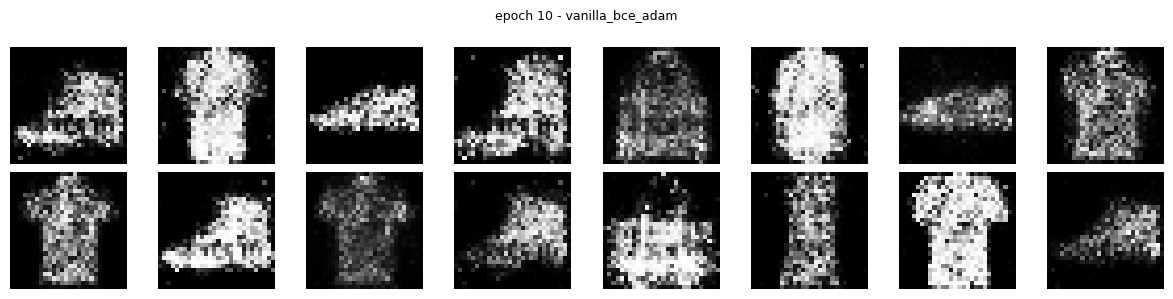

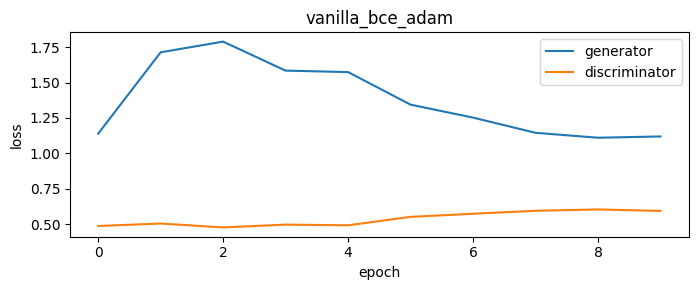

d_loss,▂▃▁▂▂▅▆▇█▇
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▇█▆▆▃▂▁▁▁
d_loss,0.59502
epoch,10
g_loss,1.11982



starting: vanilla_bce_sgd


  epoch 1/10  g_loss=0.7753  d_loss=0.3865
  epoch 2/10  g_loss=1.5372  d_loss=0.2969
  epoch 3/10  g_loss=2.3564  d_loss=0.1835
  epoch 4/10  g_loss=2.7525  d_loss=0.1495
  epoch 5/10  g_loss=3.0711  d_loss=0.1419


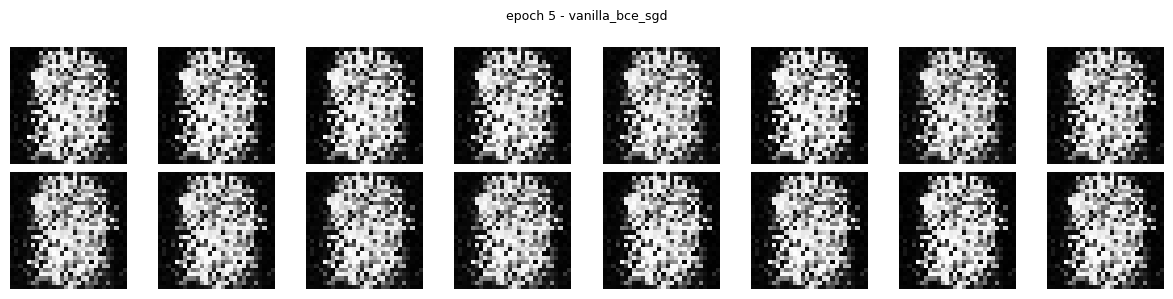

  epoch 6/10  g_loss=3.4085  d_loss=0.1637
  epoch 7/10  g_loss=3.4162  d_loss=0.2322
  epoch 8/10  g_loss=3.2903  d_loss=0.2080
  epoch 9/10  g_loss=3.3892  d_loss=0.1470
  epoch 10/10  g_loss=3.6825  d_loss=0.1409


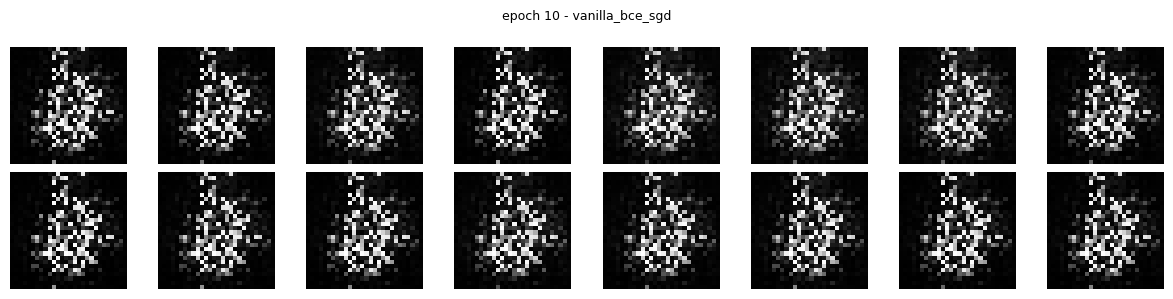

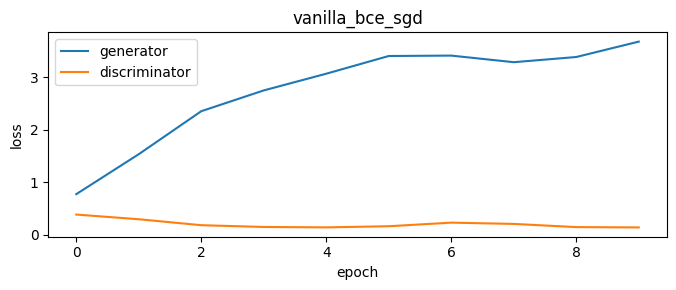

d_loss,█▅▂▁▁▂▄▃▁▁
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▃▅▆▇▇▇▇▇█
d_loss,0.14091
epoch,10
g_loss,3.68246



starting: vanilla_bce_rmsprop


  epoch 1/10  g_loss=0.8298  d_loss=0.4790
  epoch 2/10  g_loss=1.4172  d_loss=0.3558
  epoch 3/10  g_loss=2.0724  d_loss=0.2976
  epoch 4/10  g_loss=2.4923  d_loss=0.2660
  epoch 5/10  g_loss=2.7206  d_loss=0.2431


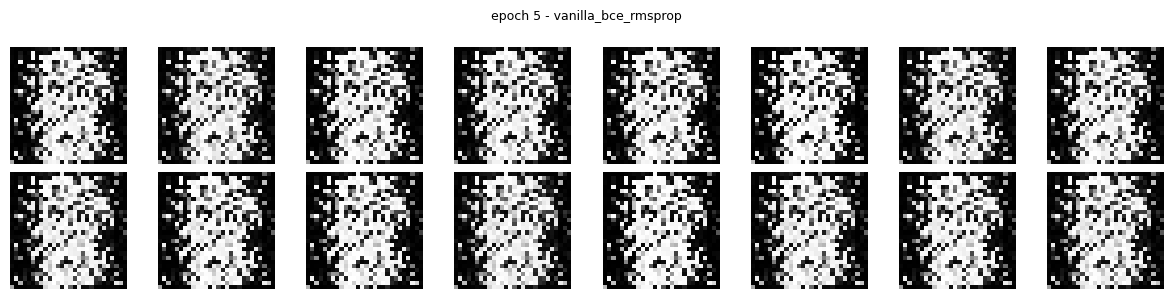

  epoch 6/10  g_loss=2.9377  d_loss=0.2522
  epoch 7/10  g_loss=2.9658  d_loss=0.2494
  epoch 8/10  g_loss=3.2878  d_loss=0.2254
  epoch 9/10  g_loss=3.0941  d_loss=0.2695
  epoch 10/10  g_loss=3.0596  d_loss=0.2483


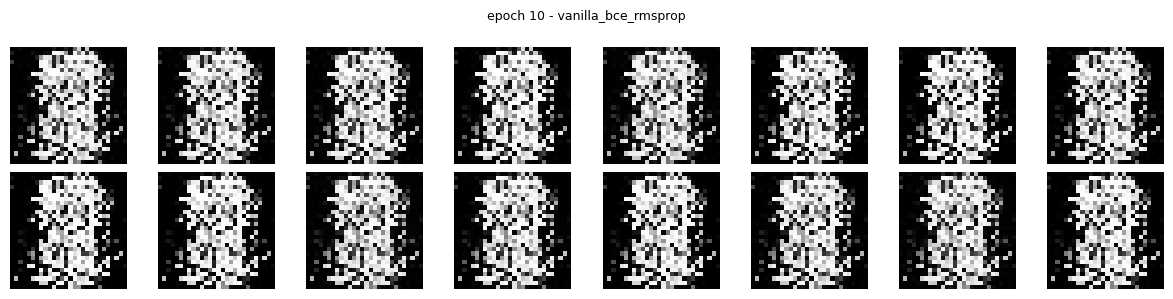

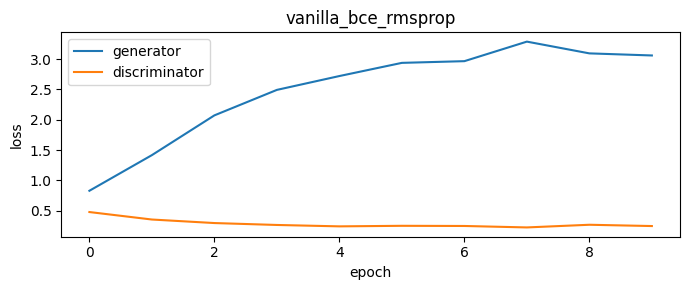

d_loss,█▅▃▂▁▂▂▁▂▂
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▃▅▆▆▇▇█▇▇
d_loss,0.24826
epoch,10
g_loss,3.05965



starting: vanilla_lsgan_adam


  epoch 1/10  g_loss=1.0183  d_loss=0.0731
  epoch 2/10  g_loss=0.7942  d_loss=0.1198
  epoch 3/10  g_loss=0.7068  d_loss=0.1419
  epoch 4/10  g_loss=0.6031  d_loss=0.1601
  epoch 5/10  g_loss=0.5539  d_loss=0.1752


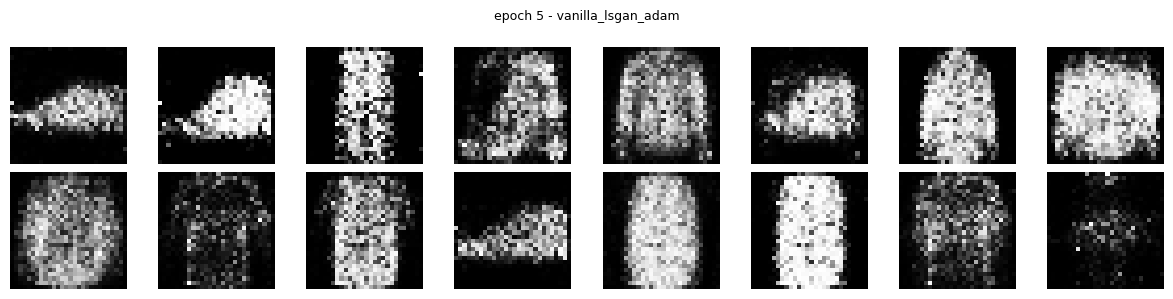

  epoch 6/10  g_loss=0.5195  d_loss=0.1819
  epoch 7/10  g_loss=0.5039  d_loss=0.1866
  epoch 8/10  g_loss=0.4799  d_loss=0.1917
  epoch 9/10  g_loss=0.4603  d_loss=0.2003
  epoch 10/10  g_loss=0.4493  d_loss=0.2020


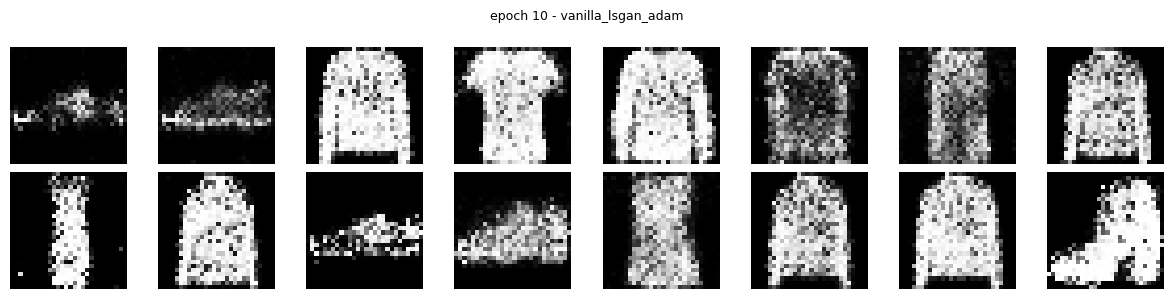

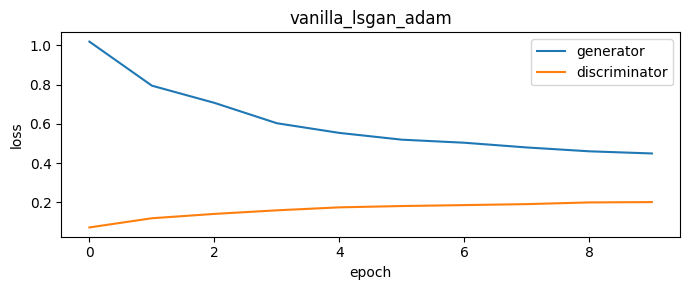

d_loss,▁▄▅▆▇▇▇▇██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▅▄▃▂▂▂▁▁▁
d_loss,0.202
epoch,10
g_loss,0.44931



starting: vanilla_lsgan_sgd


  epoch 1/10  g_loss=0.7247  d_loss=0.0394
  epoch 2/10  g_loss=1.0189  d_loss=0.0296
  epoch 3/10  g_loss=0.9891  d_loss=0.0211
  epoch 4/10  g_loss=0.9802  d_loss=0.0242
  epoch 5/10  g_loss=0.9533  d_loss=0.0260


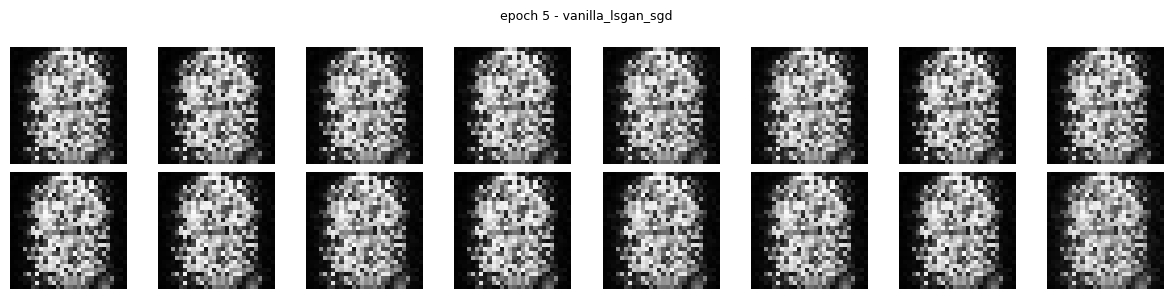

  epoch 6/10  g_loss=0.9405  d_loss=0.0261
  epoch 7/10  g_loss=0.9430  d_loss=0.0259
  epoch 8/10  g_loss=0.9646  d_loss=0.0281
  epoch 9/10  g_loss=0.9403  d_loss=0.0294
  epoch 10/10  g_loss=0.9552  d_loss=0.0439


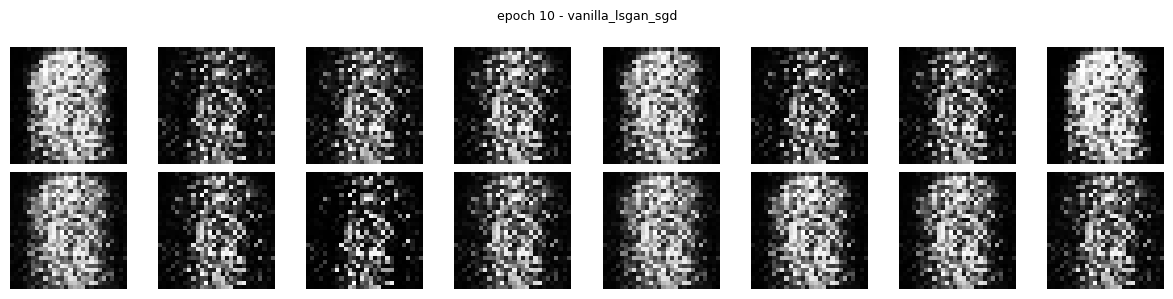

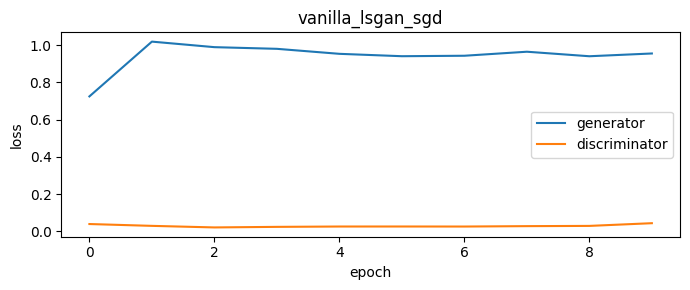

d_loss,▇▄▁▂▃▃▂▃▄█
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁█▇▇▆▆▆▇▆▆
d_loss,0.0439
epoch,10
g_loss,0.95518



starting: vanilla_lsgan_rmsprop


  epoch 1/10  g_loss=0.8773  d_loss=0.0637
  epoch 2/10  g_loss=0.9032  d_loss=0.0815
  epoch 3/10  g_loss=0.9130  d_loss=0.0849
  epoch 4/10  g_loss=0.9466  d_loss=0.0807
  epoch 5/10  g_loss=0.8935  d_loss=0.0856


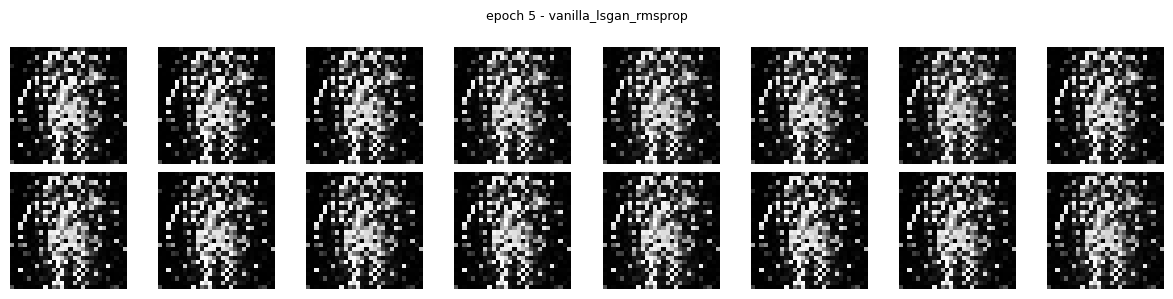

  epoch 6/10  g_loss=0.9295  d_loss=0.0854
  epoch 7/10  g_loss=0.9086  d_loss=0.0856
  epoch 8/10  g_loss=0.9415  d_loss=0.0805
  epoch 9/10  g_loss=0.9187  d_loss=0.0864
  epoch 10/10  g_loss=0.9179  d_loss=0.0877


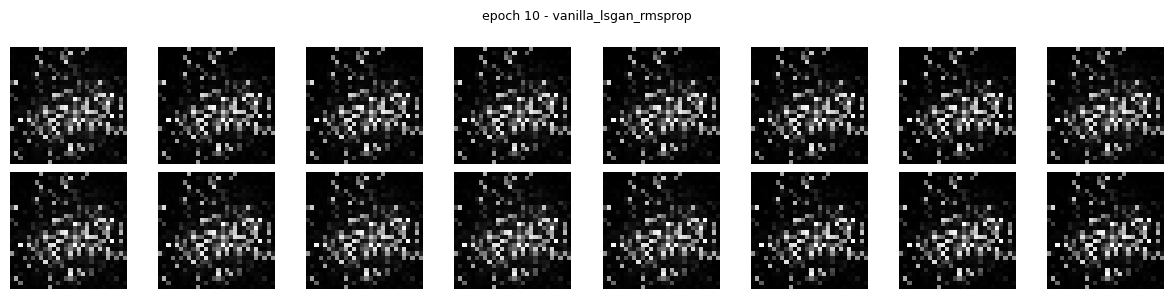

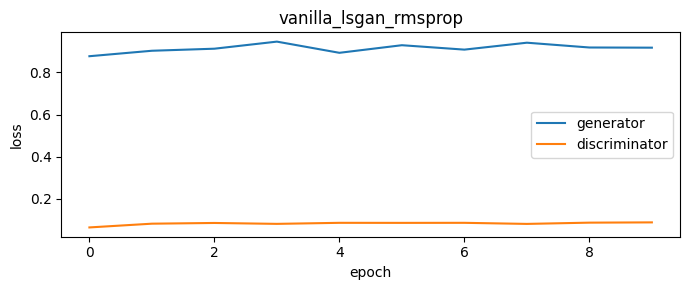

d_loss,▁▆▇▆▇▇▇▆██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▄▅█▃▆▄▇▅▅
d_loss,0.08771
epoch,10
g_loss,0.91789



starting: vanilla_wgan_adam


  epoch 1/10  g_loss=-0.1827  d_loss=-0.4512
  epoch 2/10  g_loss=-0.0682  d_loss=-0.2223
  epoch 3/10  g_loss=-0.0538  d_loss=-0.0620
  epoch 4/10  g_loss=-0.2956  d_loss=-0.2384
  epoch 5/10  g_loss=-0.1984  d_loss=-0.2013


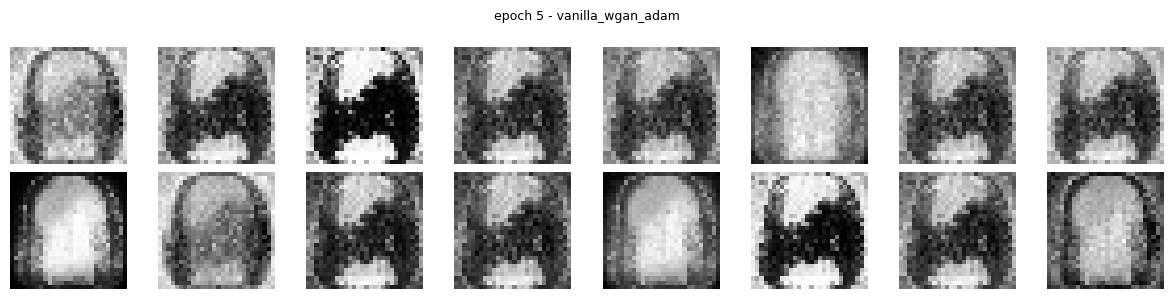

  epoch 6/10  g_loss=-0.3574  d_loss=-0.2427
  epoch 7/10  g_loss=-0.5146  d_loss=-0.1346
  epoch 8/10  g_loss=-0.4708  d_loss=-0.2423
  epoch 9/10  g_loss=-0.4110  d_loss=-0.1937
  epoch 10/10  g_loss=-0.3991  d_loss=-0.1975


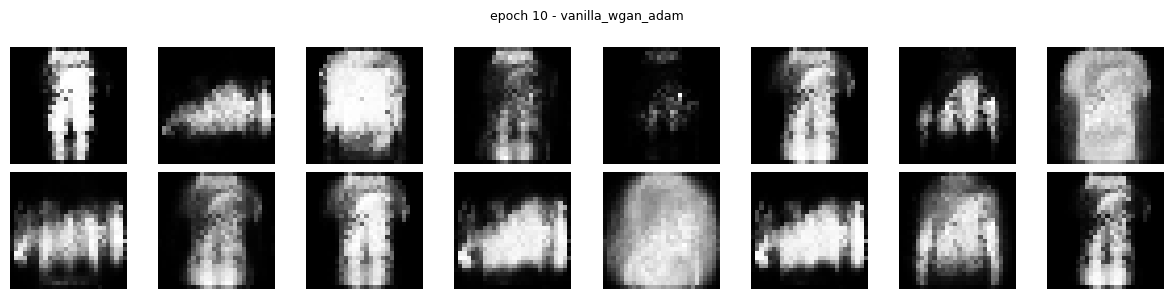

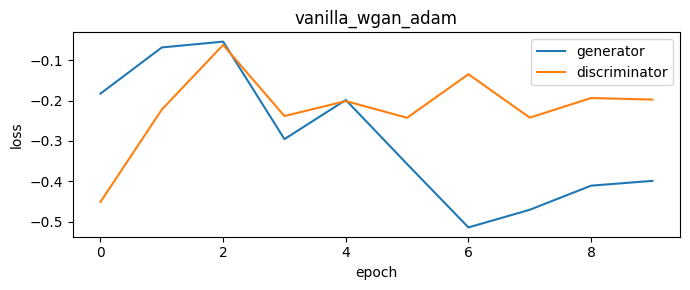

d_loss,▁▅█▅▅▅▇▅▆▆
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▆██▄▆▃▁▂▃▃
d_loss,-0.19748
epoch,10
g_loss,-0.39913



starting: vanilla_wgan_sgd


  epoch 1/10  g_loss=-0.1947  d_loss=-1.7645
  epoch 2/10  g_loss=1.9792  d_loss=-0.5985
  epoch 3/10  g_loss=2.7101  d_loss=-0.7443
  epoch 4/10  g_loss=-0.8175  d_loss=-2.5160
  epoch 5/10  g_loss=2.6305  d_loss=-1.0353


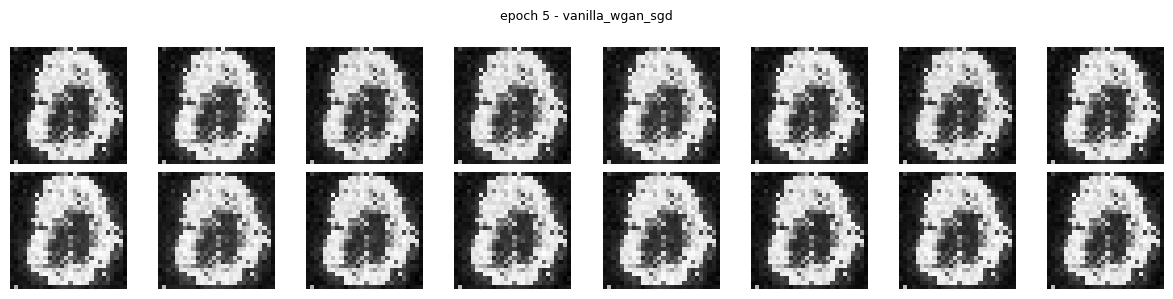

  epoch 6/10  g_loss=-3.5422  d_loss=-2.5244
  epoch 7/10  g_loss=1.6146  d_loss=-0.5495
  epoch 8/10  g_loss=2.0981  d_loss=-0.2006
  epoch 9/10  g_loss=1.1265  d_loss=-0.2500
  epoch 10/10  g_loss=-0.9626  d_loss=-0.4643


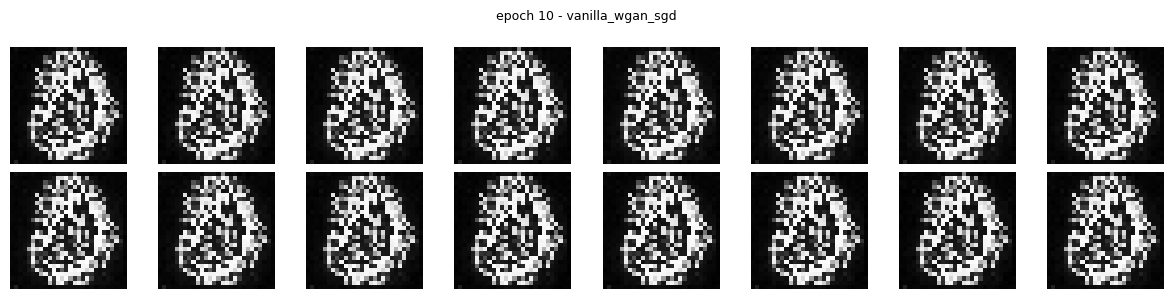

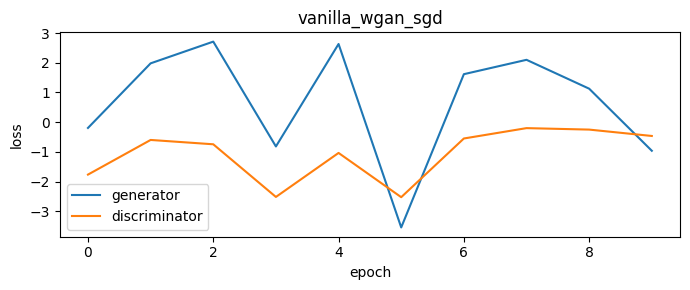

d_loss,▃▇▆▁▅▁▇██▇
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▅▇█▄█▁▇▇▆▄
d_loss,-0.46432
epoch,10
g_loss,-0.9626



starting: vanilla_wgan_rmsprop


  epoch 1/10  g_loss=-0.0876  d_loss=-0.2557
  epoch 2/10  g_loss=-0.4840  d_loss=-0.3452
  epoch 3/10  g_loss=-0.3452  d_loss=-0.4602
  epoch 4/10  g_loss=-0.4773  d_loss=-0.2114
  epoch 5/10  g_loss=-0.7481  d_loss=-0.2162


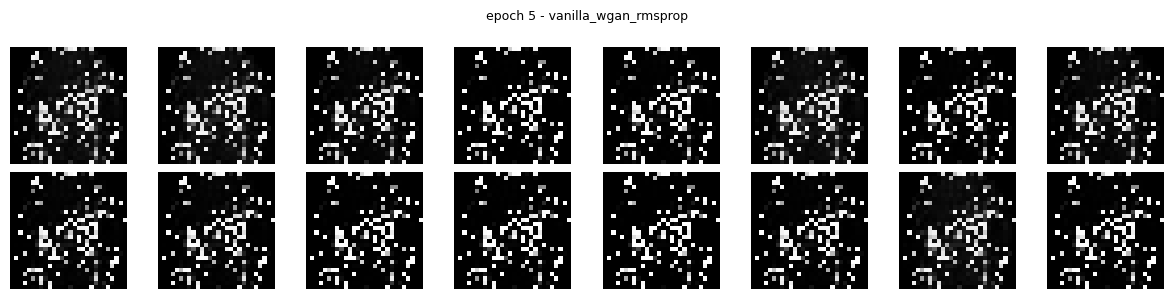

  epoch 6/10  g_loss=-0.7225  d_loss=-0.4231
  epoch 7/10  g_loss=-0.5784  d_loss=-0.5152
  epoch 8/10  g_loss=-1.1935  d_loss=-0.3628
  epoch 9/10  g_loss=-1.2653  d_loss=-0.3746
  epoch 10/10  g_loss=-0.5058  d_loss=-0.5421


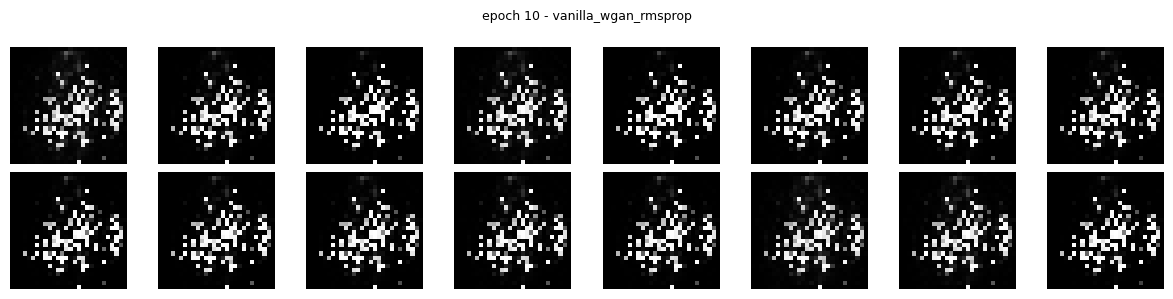

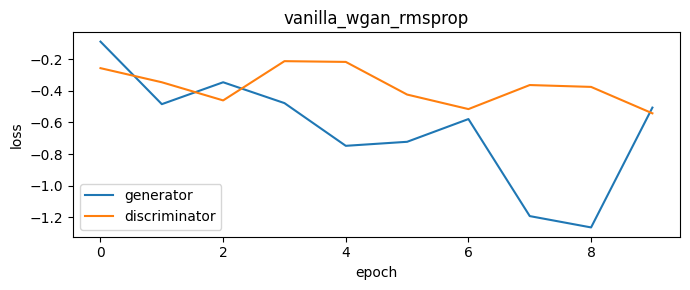

d_loss,▇▅▃██▄▂▅▅▁
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▆▆▆▄▄▅▁▁▆
d_loss,-0.54211
epoch,10
g_loss,-0.50579



starting: dcgan_bce_adam


  epoch 1/10  g_loss=5.8043  d_loss=0.0272
  epoch 2/10  g_loss=3.6319  d_loss=0.3112
  epoch 3/10  g_loss=1.2381  d_loss=0.4638
  epoch 4/10  g_loss=1.1250  d_loss=0.5069
  epoch 5/10  g_loss=1.0919  d_loss=0.5256


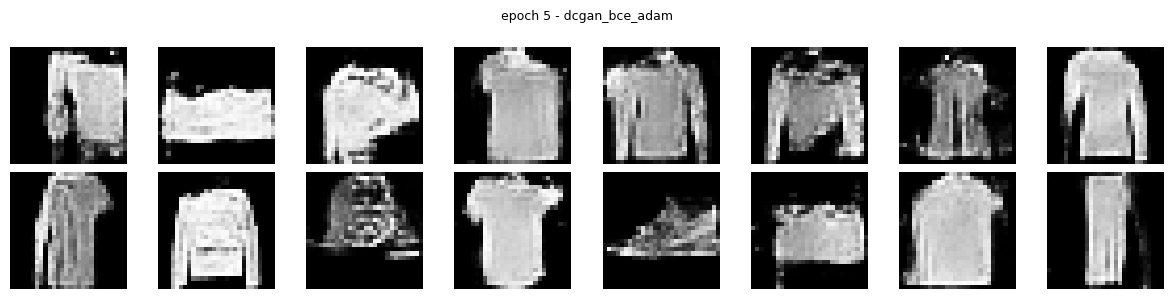

  epoch 6/10  g_loss=1.1064  d_loss=0.5186
  epoch 7/10  g_loss=1.1178  d_loss=0.5163
  epoch 8/10  g_loss=1.1191  d_loss=0.5194
  epoch 9/10  g_loss=1.1167  d_loss=0.5189
  epoch 10/10  g_loss=1.1197  d_loss=0.5232


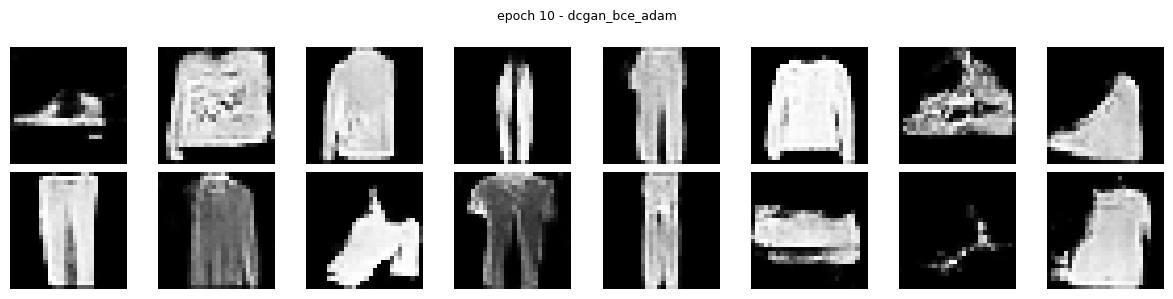

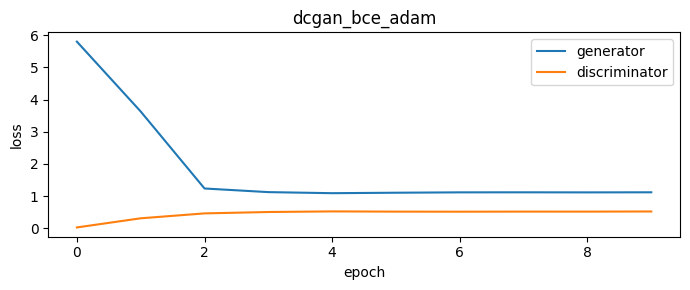

d_loss,▁▅▇███████
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▅▁▁▁▁▁▁▁▁
d_loss,0.52321
epoch,10
g_loss,1.11966



starting: dcgan_bce_sgd


  epoch 1/10  g_loss=7.0440  d_loss=0.0268
  epoch 2/10  g_loss=7.9986  d_loss=0.0008
  epoch 3/10  g_loss=8.9280  d_loss=0.0003
  epoch 4/10  g_loss=9.3282  d_loss=0.0002
  epoch 5/10  g_loss=8.8699  d_loss=0.0002


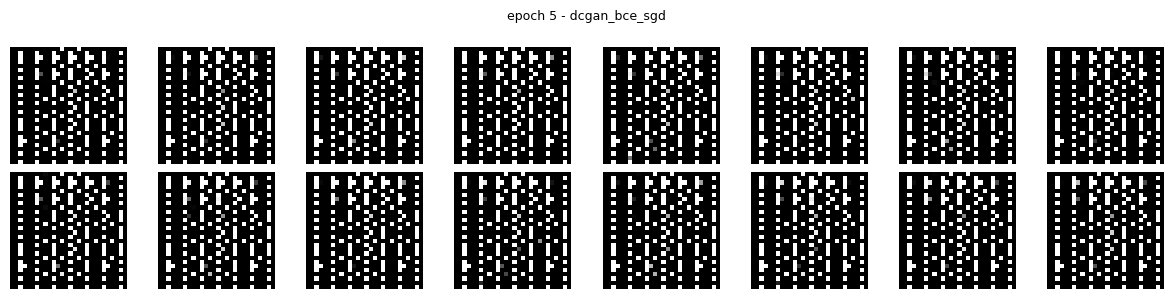

  epoch 6/10  g_loss=9.4440  d_loss=0.0001
  epoch 7/10  g_loss=9.9578  d_loss=0.0001
  epoch 8/10  g_loss=9.5985  d_loss=0.0004
  epoch 9/10  g_loss=9.4326  d_loss=0.0002
  epoch 10/10  g_loss=8.6591  d_loss=0.0003


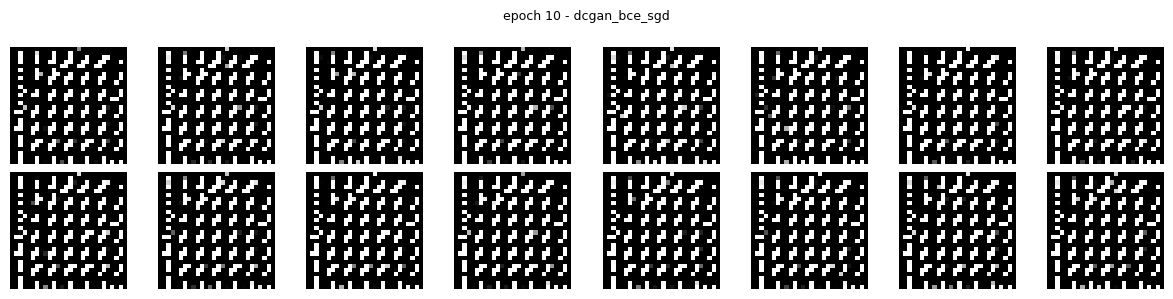

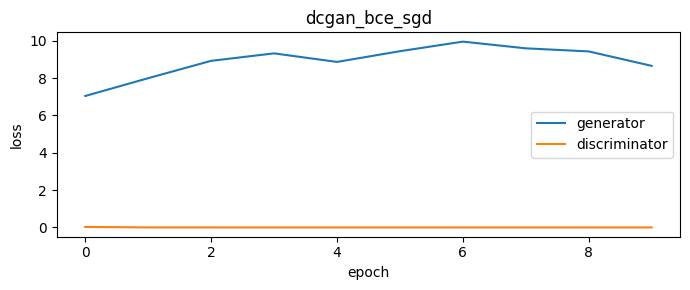

d_loss,█▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▃▆▆▅▇█▇▇▅
d_loss,0.00028
epoch,10
g_loss,8.65909



starting: dcgan_bce_rmsprop


  epoch 1/10  g_loss=1.4634  d_loss=0.3539
  epoch 2/10  g_loss=1.8798  d_loss=0.2254
  epoch 3/10  g_loss=1.8962  d_loss=0.2360
  epoch 4/10  g_loss=1.7490  d_loss=0.2776
  epoch 5/10  g_loss=1.6335  d_loss=0.3194


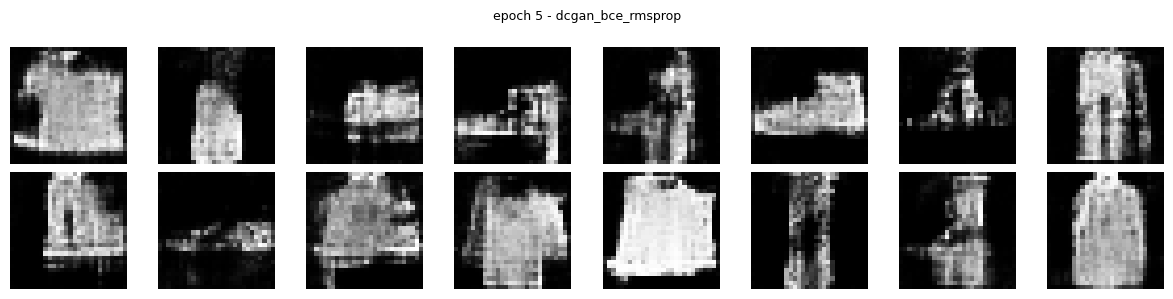

  epoch 6/10  g_loss=1.5519  d_loss=0.3511
  epoch 7/10  g_loss=1.4484  d_loss=0.3811
  epoch 8/10  g_loss=1.3899  d_loss=0.4115
  epoch 9/10  g_loss=1.3318  d_loss=0.4336
  epoch 10/10  g_loss=1.3011  d_loss=0.4489


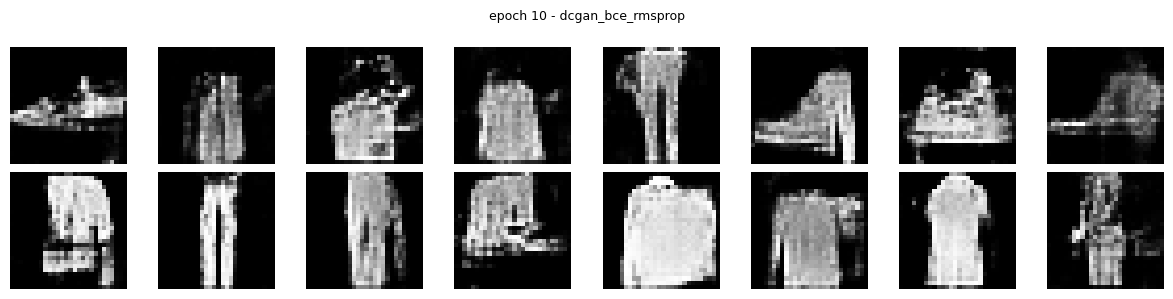

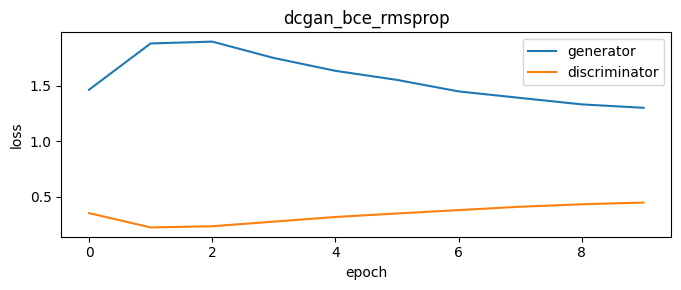

d_loss,▅▁▁▃▄▅▆▇██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▃██▆▅▄▃▂▁▁
d_loss,0.44893
epoch,10
g_loss,1.30105



starting: dcgan_lsgan_adam


  epoch 1/10  g_loss=1.0624  d_loss=0.0407
  epoch 2/10  g_loss=1.0385  d_loss=0.0218
  epoch 3/10  g_loss=1.0738  d_loss=0.0343
  epoch 4/10  g_loss=0.6139  d_loss=0.1530
  epoch 5/10  g_loss=0.4842  d_loss=0.1668


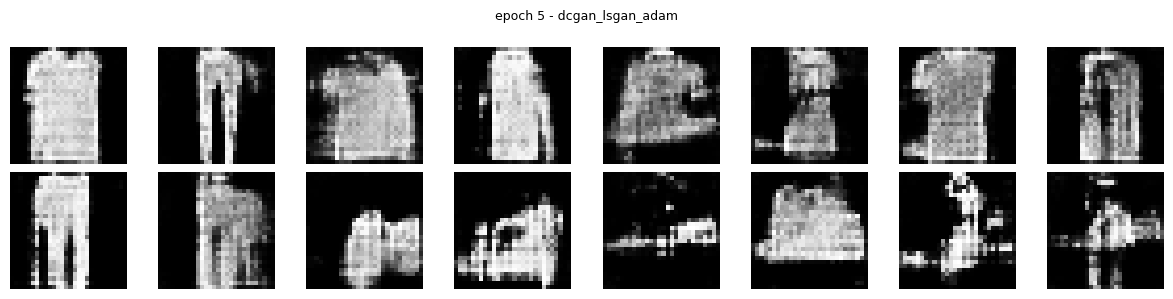

  epoch 6/10  g_loss=0.4453  d_loss=0.1843
  epoch 7/10  g_loss=0.4279  d_loss=0.1964
  epoch 8/10  g_loss=0.4096  d_loss=0.2001
  epoch 9/10  g_loss=0.4775  d_loss=0.1919
  epoch 10/10  g_loss=0.4989  d_loss=0.1829


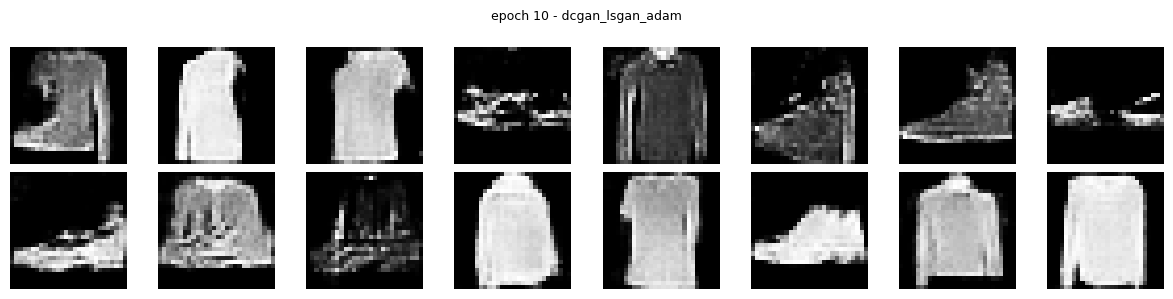

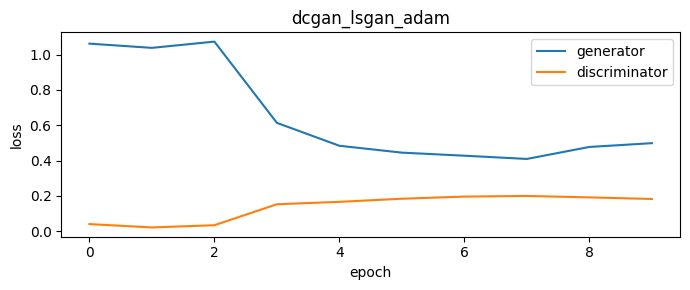

d_loss,▂▁▁▆▇▇███▇
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,███▃▂▁▁▁▂▂
d_loss,0.18291
epoch,10
g_loss,0.49892



starting: dcgan_lsgan_sgd


  epoch 1/10  g_loss=2.4883  d_loss=0.8017
  epoch 2/10  g_loss=1.0420  d_loss=0.0143
  epoch 3/10  g_loss=1.0035  d_loss=0.0038
  epoch 4/10  g_loss=1.0051  d_loss=0.0024
  epoch 5/10  g_loss=1.0011  d_loss=0.0018


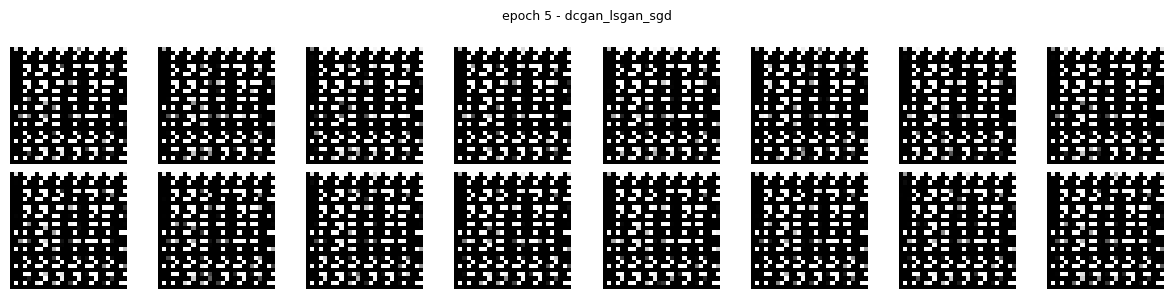

  epoch 6/10  g_loss=1.0025  d_loss=0.0018
  epoch 7/10  g_loss=1.0019  d_loss=0.0016
  epoch 8/10  g_loss=1.0012  d_loss=0.0014
  epoch 9/10  g_loss=1.0006  d_loss=0.0012
  epoch 10/10  g_loss=1.0009  d_loss=0.0012


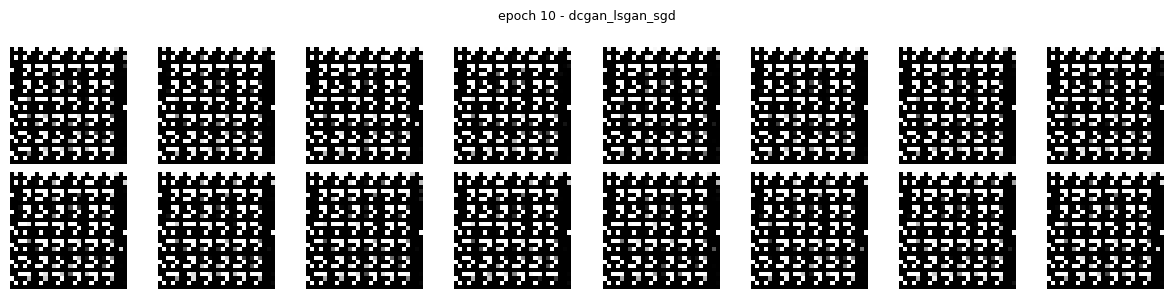

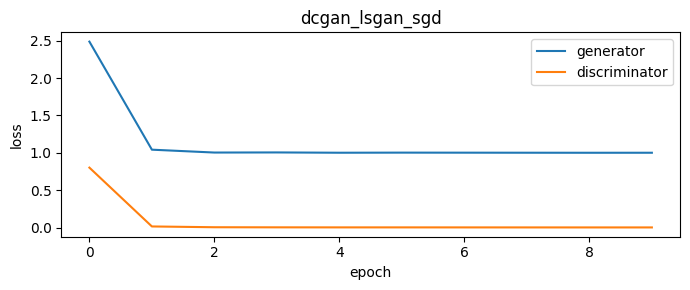

d_loss,█▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▁▁▁▁▁▁▁▁▁
d_loss,0.00119
epoch,10
g_loss,1.00091



starting: dcgan_lsgan_rmsprop


  epoch 1/10  g_loss=0.5298  d_loss=0.1941
  epoch 2/10  g_loss=0.6253  d_loss=0.1054
  epoch 3/10  g_loss=0.6390  d_loss=0.1001
  epoch 4/10  g_loss=0.5507  d_loss=0.1279
  epoch 5/10  g_loss=0.5023  d_loss=0.1471


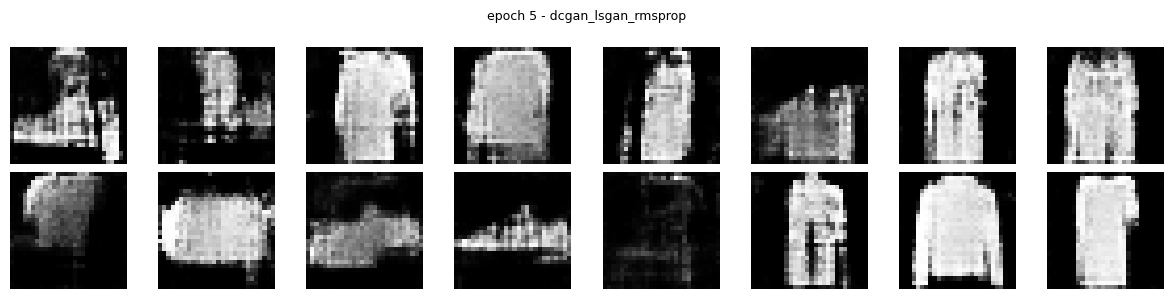

  epoch 6/10  g_loss=0.4757  d_loss=0.1606
  epoch 7/10  g_loss=0.4468  d_loss=0.1744
  epoch 8/10  g_loss=0.4203  d_loss=0.1855
  epoch 9/10  g_loss=0.4045  d_loss=0.1955
  epoch 10/10  g_loss=0.3915  d_loss=0.2010


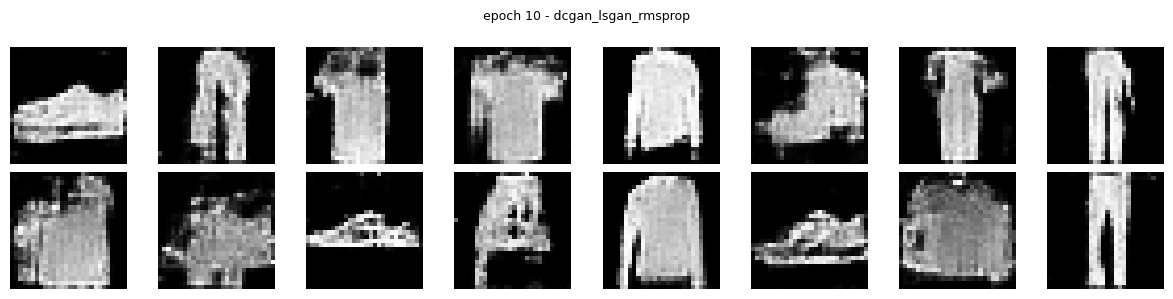

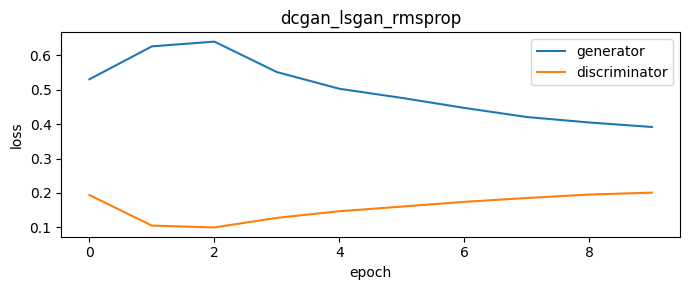

d_loss,█▁▁▃▄▅▆▇██
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▅██▆▄▃▃▂▁▁
d_loss,0.20104
epoch,10
g_loss,0.39146



starting: dcgan_wgan_adam


  epoch 1/10  g_loss=0.0319  d_loss=-0.0243
  epoch 2/10  g_loss=0.0191  d_loss=-0.0083
  epoch 3/10  g_loss=0.0095  d_loss=-0.0075
  epoch 4/10  g_loss=0.0065  d_loss=-0.0075
  epoch 5/10  g_loss=0.0031  d_loss=-0.0063


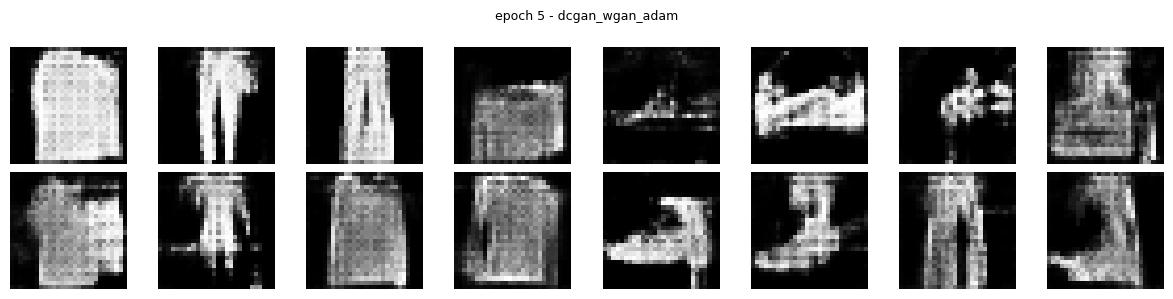

  epoch 6/10  g_loss=0.0016  d_loss=-0.0050
  epoch 7/10  g_loss=-0.0024  d_loss=-0.0040
  epoch 8/10  g_loss=0.0024  d_loss=-0.0040
  epoch 9/10  g_loss=0.0021  d_loss=-0.0033
  epoch 10/10  g_loss=-0.0062  d_loss=-0.0028


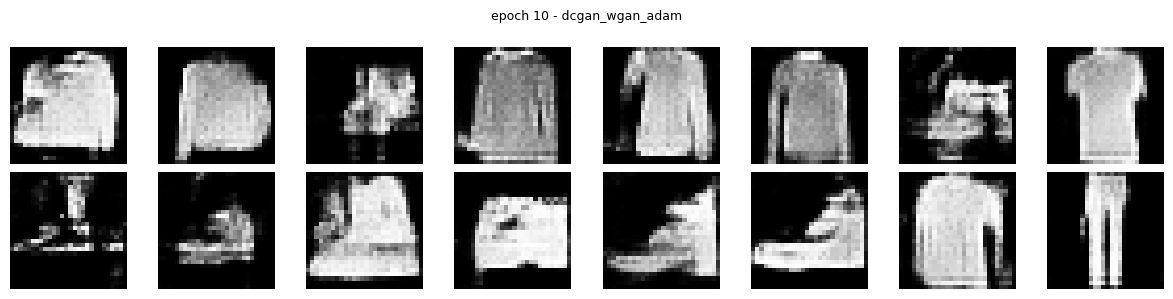

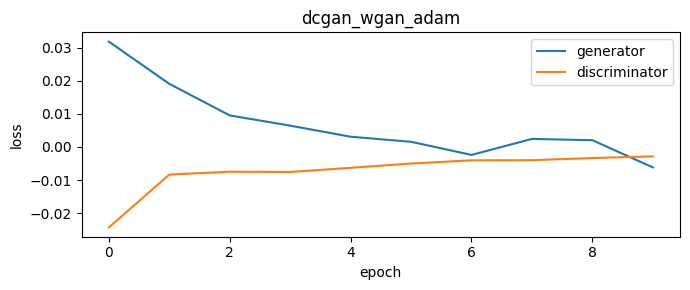

d_loss,▁▆▆▆▇▇████
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,█▆▄▃▃▂▂▃▃▁
d_loss,-0.00282
epoch,10
g_loss,-0.00616



starting: dcgan_wgan_sgd


  epoch 1/10  g_loss=0.1655  d_loss=-0.3447
  epoch 2/10  g_loss=0.3986  d_loss=-0.7308
  epoch 3/10  g_loss=0.4210  d_loss=-0.8021
  epoch 4/10  g_loss=0.3942  d_loss=-0.7878
  epoch 5/10  g_loss=0.3826  d_loss=-0.6049


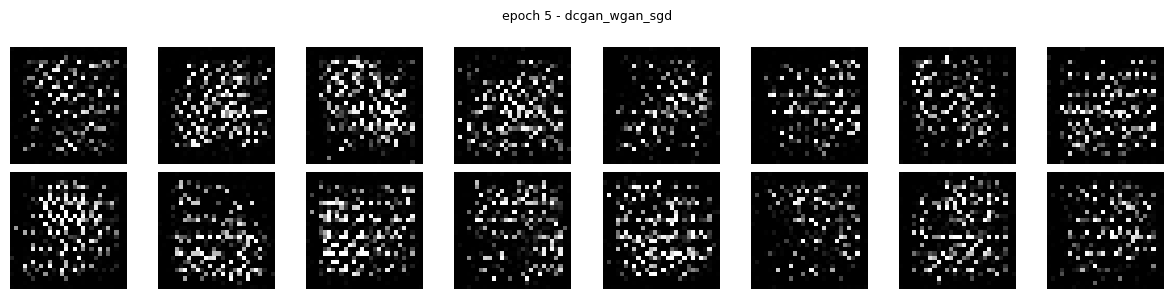

  epoch 6/10  g_loss=0.3188  d_loss=-0.5643
  epoch 7/10  g_loss=0.1992  d_loss=-0.3873
  epoch 8/10  g_loss=0.2843  d_loss=-0.4035
  epoch 9/10  g_loss=0.2954  d_loss=-0.3865
  epoch 10/10  g_loss=0.2706  d_loss=-0.3450


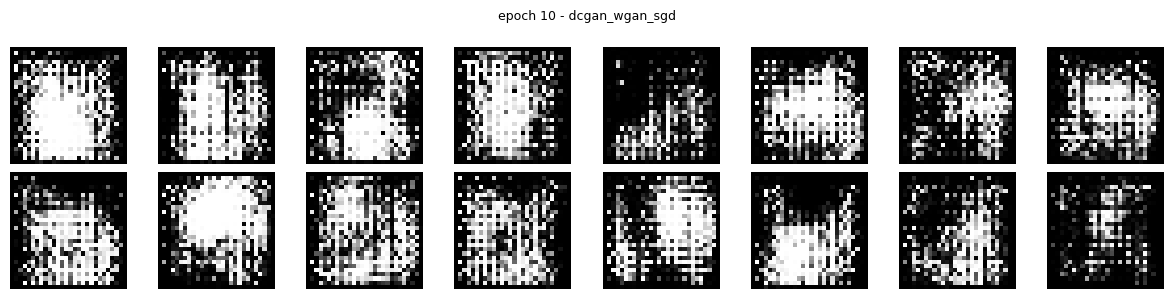

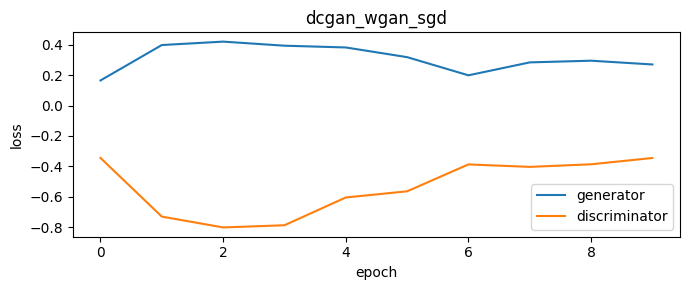

d_loss,█▂▁▁▄▅▇▇▇█
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▁▇█▇▇▅▂▄▅▄
d_loss,-0.34501
epoch,10
g_loss,0.27063



starting: dcgan_wgan_rmsprop


  epoch 1/10  g_loss=0.0424  d_loss=-0.1341
  epoch 2/10  g_loss=0.0585  d_loss=-0.0154
  epoch 3/10  g_loss=0.0624  d_loss=-0.0331
  epoch 4/10  g_loss=0.0512  d_loss=-0.0271
  epoch 5/10  g_loss=0.0447  d_loss=-0.0190


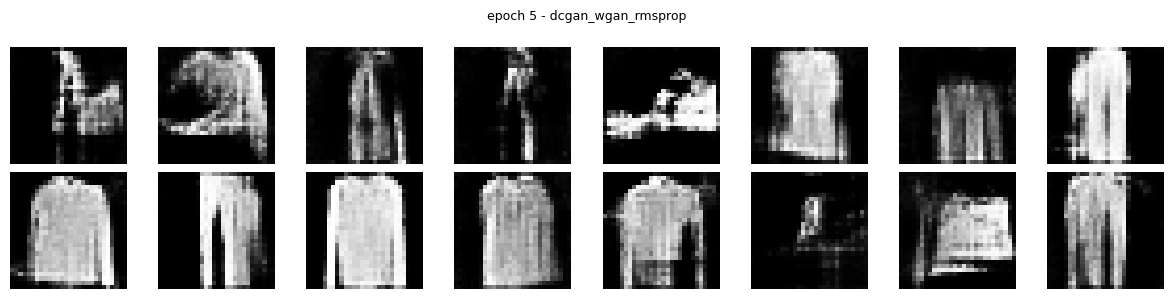

  epoch 6/10  g_loss=0.0433  d_loss=-0.0142
  epoch 7/10  g_loss=0.0410  d_loss=-0.0115
  epoch 8/10  g_loss=0.0411  d_loss=-0.0096
  epoch 9/10  g_loss=0.0391  d_loss=-0.0082
  epoch 10/10  g_loss=0.0357  d_loss=-0.0073


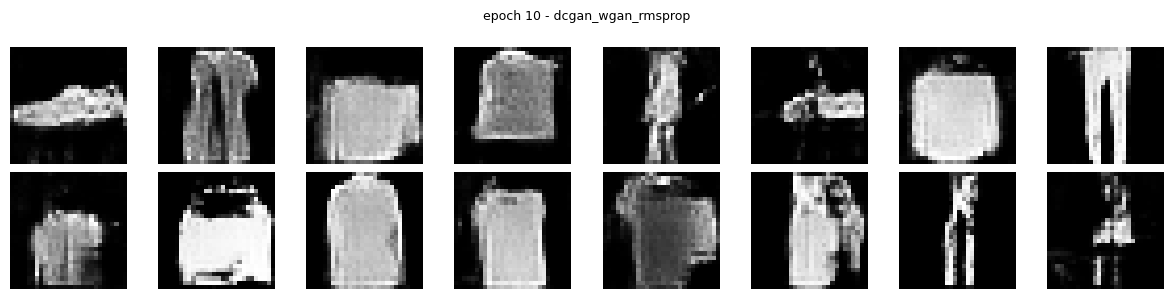

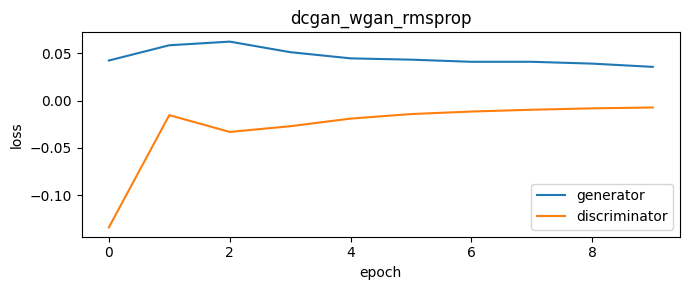

d_loss,▁█▇▇▇█████
epoch,▁▂▃▃▄▅▆▆▇█
g_loss,▃▇█▅▃▃▂▂▂▁
d_loss,-0.00726
epoch,10
g_loss,0.03567


In [ ]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [ ]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_sgd                       -0.9626    -0.4643
vanilla_wgan_rmsprop                   -0.5058    -0.5421
vanilla_wgan_adam                      -0.3991    -0.1975
dcgan_wgan_adam                        -0.0062    -0.0028
dcgan_wgan_rmsprop                      0.0357    -0.0073
dcgan_wgan_sgd                          0.2706    -0.3450
dcgan_lsgan_rmsprop                     0.3915     0.2010
vanilla_lsgan_adam                      0.4493     0.2020
dcgan_lsgan_adam                        0.4989     0.1829
vanilla_lsgan_rmsprop                   0.9179     0.0877
vanilla_lsgan_sgd                       0.9552     0.0439
dcgan_lsgan_sgd                         1.0009     0.0012
dcgan_bce_adam                          1.1197     0.5232
vanilla_bce_adam                        1.1198     0.5950
dcgan_bce_rmsprop                       1.3011     0.4489
vanilla_bce_rm